In [1]:
import ipywidgets as widgets
from IPython.display import display, HTML
#יצירת צ'ק ליסט קיים אינטרקטיבי ע"י בינה מלאכתוית כעזר למעקב אחר הפרוקיט והתקדמותו
# 1. עיצוב CSS מותאם ליישור לימין
display(
    HTML("""
<style>
    .rtl-checklist {
        direction: rtl !important;
        text-align: right !important;
    }
    .rtl-checklist .widget-checkbox {
        flex-direction: row-reverse !important;
        justify-content: flex-end !important;
    }
    .rtl-checklist .widget-checkbox label {
        margin-right: 8px !important;
        margin-left: 0px !important;
    }
</style>
""")
)

# 2. הגדרת המשימות והשלבים
tasks_data = [
    # חלק 1
    ("--- 1. הכנת הנתונים והסביבה ---", "header"),
    ("התקנת הספריות הנדרשות לפיתוח", "task"),
    ("הורדת ה-Dataset מ-Kaggle", "task"),
    ("טיפול בערכים חסרים בדאטה", "task"),
    ("בחירת 5–7 פיצ'רים + עמודת Target", "task"),
    # חלק 2
    ("--- 2. אימון המודל וה-Pipeline ---", "header"),
    ("המרת משתנים קטגוריאליים לערכים נומריים", "task"),
    ("פיצול הנתונים ל-Train ו-Test", "task"),
    ("בניית Pipeline המשולב StandardScaler ו-SVC", "task"),
    ("אימון ה-Pipeline על נתוני האימון (fit)", "task"),
    (
        "חישוב מטריקות הערכה (Accuracy, Confusion Matrix, Classification"
        " Report)",
        "task",
    ),
    ("שמירת ה-Pipeline והנתונים המורחבים לקובץ (.pkl)", "task"),
    # חלק 3
    ("--- 3. שרת FastAPI ---", "header"),
    ("הקמת תשתית השרת ב-FastAPI", "task"),
    (
        "מנגנון טעינת קובץ המודל בעליית השרת (כולל טיפול במקרה של קובץ חסר)",
        "task",
    ),
    ("יצירת Endpoint למידע כללי והיפר-פרמטרים (/model/info)", "task"),
    ("יצירת Endpoint לרשימת הפיצ'רים (/model/features)", "task"),
    ("יצירת Endpoint לנתוני הדגימות (/model/samples)", "task"),
    ("יצירת Endpoint למטריקות וביצועים (/model/metrics)", "task"),
    ("יצירת Endpoint לווקטורים התומכים (/model/support_vectors)", "task"),
    ("יצירת Endpoint לקבלת נתוני משתמש והחזרת חיזוי (/predict)", "task"),
    # חלק 4
    ("--- 4. ממשק המשתמש (HTML / Frontend) ---", "header"),
    (
        "בניית דף Dashboard מקיף להצגת נתוני ומטריקות המודל דרך ה-API",
        "task",
    ),
    ("הצגת גרף/ויזואליזציה של Margin Distribution / Decision Boundary", "task"),
    ("בניית דף טופס קליטת נתונים מהמשתמש (Loan Approval Checker)", "task"),
    ("חיבור כפתור ה-Check ל-API להרצת החיזוי", "task"),
    ("הצגת תוצאת החיזוי הוויזואלית (מאושר / לא מאושר)", "task"),
    # חלק 5
    ("--- 5. איכות, בדיקות והגשה ---", "header"),
    ("בדיקת התנהגות המערכת כשקובץ המודל חסר", "task"),
    ("כתיבת תיעוד (Docstrings) בקוד", "task"),
    ("הוספת לוגים (רשות - בונוס)", "task"),
    ("העלאת האפליקציה ל-Render (רשות - בונוס)", "task"),
    ("העלאת הקוד והמודל ל-GitHub", "task"),
]

checkboxes = []
ui_elements = []

# 3. יצירת רכיבי הממשק
for item, item_type in tasks_data:
    if item_type == "header":
        ui_elements.append(widgets.HTML(value=f"<h4 style='margin-top:15px; margin-bottom:5px; text-align:right;'>{item}</h4>"))
    else:
        cb = widgets.Checkbox(value=False, description=item, indent=False, layout=widgets.Layout(width='auto'))
        checkboxes.append(cb)
        ui_elements.append(cb)

# מד התקדמות
progress = widgets.IntProgress(
    value=0,
    min=0,
    max=len(checkboxes),
    description='התקדמות:',
    bar_style='info',
    orientation='horizontal',
    layout=widgets.Layout(width='300px')
)

progress_label = widgets.Label(value=f"0 / {len(checkboxes)} (0%)")

# עדכון מד ההתקדמות בזמן אמת
def update_progress(change):
    completed = sum(1 for cb in checkboxes if cb.value)
    progress.value = completed
    percent = int((completed / len(checkboxes)) * 100)
    progress_label.value = f"{completed} / {len(checkboxes)} ({percent}%)"
    
    if completed == len(checkboxes):
        progress.bar_style = 'success'
    else:
        progress.bar_style = 'info'

for cb in checkboxes:
    cb.observe(update_progress, names='value')

# 4. עטיפת כל הווידג'טים בקופסה מימין לשמאל
header_box = widgets.HBox([progress_label, progress])
checklist_box = widgets.VBox([header_box] + ui_elements)

# הוספת מחלקת ה-RTL לקופסה הראשית
checklist_box.add_class("rtl-checklist")

display(checklist_box)

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#reading the csv
db = pd.read_csv('project_loan_approval_DB_V2.csv')
#checking if there are NaN
display(db.isna().sum())
#making sure there are no one below 18
db.sort_values('person_age', ascending = True)

#filltring the data based on the data i want to train into a new Data Base
train_db = db.copy()
train_db = train_db.drop(['person_age','person_gender','person_education','person_home_ownership','loan_intent',
                          'cb_person_cred_hist_length'], axis = 1)

#making the column '['previous_loan_defaults_on_file']' to be numeric and not string
train_db['previous_loan_defaults_on_file'] = train_db['previous_loan_defaults_on_file'].map({'No' : 0 , 'Yes' : 1})
display(train_db)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,29958.61,13,4923.19,15.32,0.16,608,1,0
1,103953.94,4,35000.00,15.38,0.34,608,0,1
2,51507.44,13,17642.82,16.54,0.34,501,1,0
3,76598.94,13,12694.67,14.87,0.17,633,0,0
4,44134.42,3,12462.46,15.61,0.28,588,0,0
...,...,...,...,...,...,...,...,...
11995,71097.07,23,11086.21,17.18,0.16,620,1,0
11996,26371.24,1,13540.44,16.78,0.51,592,1,0
11997,27586.56,20,7764.84,19.17,0.28,585,0,0
11998,64217.59,10,13853.73,17.88,0.22,553,1,0


In [4]:
# 1. Split Data
y_label = train_db['loan_status']
x_features = train_db.drop(['loan_status'], axis=1)
x_train, x_test, y_train, y_test = train_test_split(x_features, y_label, test_size=0.2, random_state=42, stratify=y_label)

# 2. Scale Data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression()
model.fit(x_train_scaled, y_train)

coefficients = model.coef_[0] 

coef_df = pd.DataFrame({'Feature': x_features.columns,'Coefficient': coefficients}).sort_values(by='Coefficient', ascending=False)
print(coef_df)


                          Feature  Coefficient
5                    credit_score     0.729725
0                   person_income     0.113693
1                  person_emp_exp     0.012825
2                       loan_amnt    -0.041675
3                   loan_int_rate    -0.359207
4             loan_percent_income    -0.417188
6  previous_loan_defaults_on_file    -1.474043


In [6]:
                                        ########  creating the pipline - manually first try ########

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('loan_model', SVC(kernel='rbf'))  
    ])

pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
print("prediction:", y_pred[:10])
print("true:      ", y_test[:10].values)
print()
print("Confusion matrix:\n", cm)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

prediction: [0 1 0 0 0 0 0 0 0 0]
true:       [0 1 0 0 0 0 0 0 0 0]

Confusion matrix:
 [[1707  159]
 [ 179  355]]
Accuracy: 0.8591666666666666
Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1866
           1       0.69      0.66      0.68       534

    accuracy                           0.86      2400
   macro avg       0.80      0.79      0.79      2400
weighted avg       0.86      0.86      0.86      2400



In [7]:
                              ########  creating the pipline - using cross validation - seacond try ########

C_range = [0.1, 1, 10]
best_score = 0
best_C = None
best_pipeline = None

for c_val in C_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', C=c_val))
    ])

    scores = cross_val_score(
        pipe, 
        x_train, 
        y_train, 
        cv=5, 
        scoring='accuracy'
    )

    mean_score = np.mean(scores)
    print(f"Testing C={c_val} | Mean Accuracy: {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_C = c_val
        best_pipeline = pipe

print("-" * 40)
print(f"The winning parameter is C={best_C} with an accuracy of {best_score:.4f}")

best_pipeline.fit(x_train, y_train)

y_pred_best = best_pipeline.predict(x_test)
print("\nAccuracy:\n", accuracy_score(y_test, y_pred_best))
print("Confusion matrix:\n", cm)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_best))

Testing C=0.1 | Mean Accuracy: 0.8545
Testing C=1 | Mean Accuracy: 0.8528
Testing C=10 | Mean Accuracy: 0.8521
----------------------------------------
The winning parameter is C=0.1 with an accuracy of 0.8545

Accuracy:
 0.8633333333333333
Confusion matrix:
 [[1707  159]
 [ 179  355]]
Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1866
           1       0.71      0.65      0.68       534

    accuracy                           0.86      2400
   macro avg       0.81      0.79      0.80      2400
weighted avg       0.86      0.86      0.86      2400



In [8]:
                    ########  creating the pipline - using cross validation inside a function - third try ########

def find_best_svc_pipeline(x_train, y_train, C_range, cv=5):
    """
    Performs a hyperparameter search over C for an SVC (kernel='rbf') 
    using Cross-Validation, and returns the fitted Pipeline with the 
    best-performing C value.

    Args:
        x_train - the normalizetion is happening inside the pipline
        y_train - the correct labels
        C_range - checking C for each point
        cv - the number of "splits" of the data inside x_train to make the evaluation more relaible

    Returns:
        tuple: best_pipeline: Pipeline of x_train
                best_C: value C
                best_score: the "winning" mean Accuracy
    """
    best_score = 0
    best_C = None
    best_pipeline = None

    for c_val in C_range:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVC(kernel='rbf', C=c_val))
        ])
        scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='accuracy')
        mean_score = np.mean(scores)
        print(f"Testing C={c_val} | Mean Accuracy: {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_C = c_val
            best_pipeline = pipe
            
    print("-" * 40)
    print(f"The winning parameter is C={best_C} with an accuracy of {best_score:.4f}")
    best_pipeline.fit(x_train, y_train)
    y_pred_best = best_pipeline.predict(x_test)
    print("\nAccuracy:\n", accuracy_score(y_test, y_pred_best))
    print("Confusion matrix:\n", cm)
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred_best))
    return best_pipeline, best_C, best_score
best_pipeline, best_C, best_score = find_best_svc_pipeline(x_train, y_train, C_range=[0.1, 1, 10])

Testing C=0.1 | Mean Accuracy: 0.8545
Testing C=1 | Mean Accuracy: 0.8528
Testing C=10 | Mean Accuracy: 0.8521
----------------------------------------
The winning parameter is C=0.1 with an accuracy of 0.8545

Accuracy:
 0.8633333333333333
Confusion matrix:
 [[1707  159]
 [ 179  355]]
Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1866
           1       0.71      0.65      0.68       534

    accuracy                           0.86      2400
   macro avg       0.81      0.79      0.80      2400
weighted avg       0.86      0.86      0.86      2400



In [9]:
#####explantion:
#as we can see, we have 3 testing points, when the best one is point 10 (winner), then, we using the same data on train data
#which got us the accuracy of 90.44% (very good accuracy).
#also, we can see there is NO Underfitting (that my model can't recogrize any patern) based on the Precision, Accuracy, recall and F1-score 
# Also, there is NO Overfitting as the CV score (90.29%) closely matches the Test accuracy (90.44%), proving strong generalization.

In [10]:
#saving the file as a .pkl
import joblib
joblib.dump(best_pipeline, 'project_all_ways.pkl')
print("File saved!")

File saved!


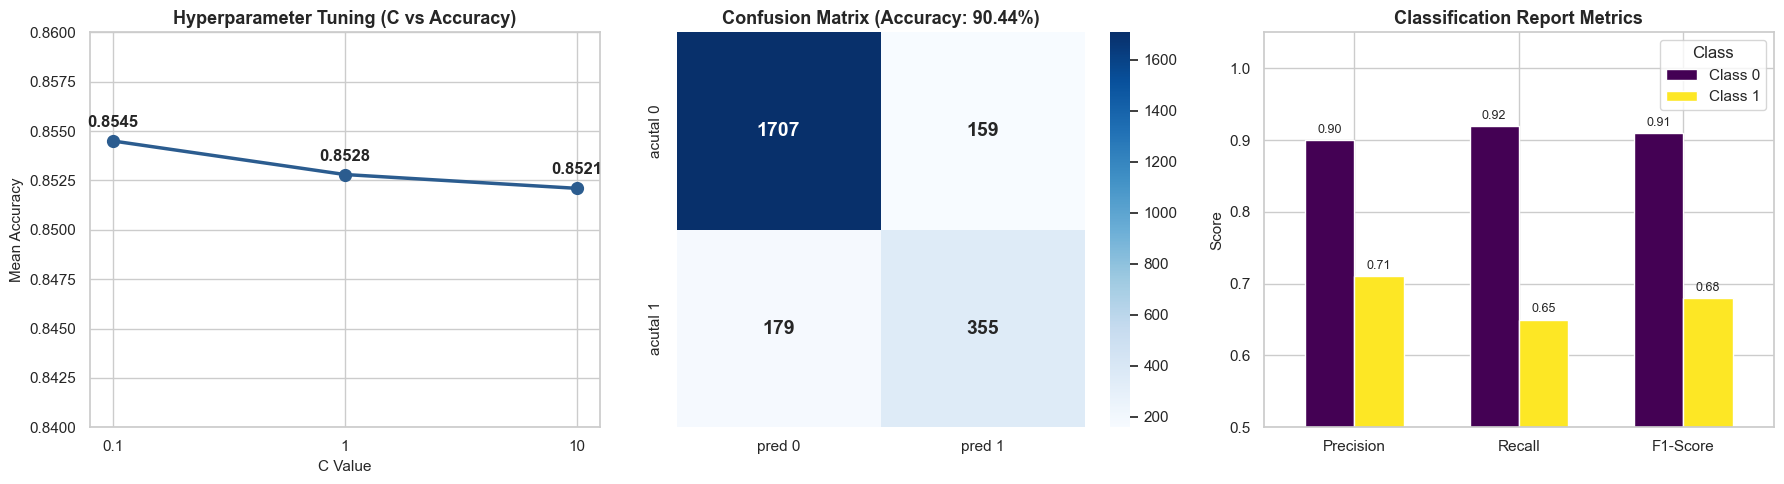

In [12]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==========================================
#   Hyperparameter Tuning: C vs Accuracy
# ==========================================
c_values = ['0.1','1','10']
mean_accuracies = [0.8545, 0.8528, 0.8521]

axes[0].plot(c_values,mean_accuracies, color='#2b5c8f',marker='o', linewidth = 2.5,markersize = 8.5)
axes[0].set_title('Hyperparameter Tuning (C vs Accuracy)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('C Value', fontsize=11)
axes[0].set_ylabel('Mean Accuracy', fontsize=11)
axes[0].set_ylim(0.84, 0.86)

for i, txt in enumerate(mean_accuracies):
  axes[0].annotate(f'{txt:.4f}',(c_values[i], mean_accuracies[i]),textcoords='offset points',xytext=(0, 10),ha='center',fontweight='bold')

# ==========================================
#        Confusion Matrix Heatmap
# ==========================================
cm = np.array([[1707  ,159],[179  ,355]])

sns.heatmap(cm,annot = True,cmap = 'Blues',fmt = 'd', ax = axes[1],annot_kws = {'size':14,'weight':'bold'},xticklabels=['pred 0','pred 1']
            ,yticklabels=['acutal 0','acutal 1'])
axes[1].set_title('Confusion Matrix (Accuracy: 90.44%)', fontsize=13, fontweight='bold')

# ==============================================
# Classification Report - Precision, Recall, F1
# ==============================================
report_data = {'Precision': [0.90, 0.71],'Recall': [0.92, 0.65],'F1-Score': [0.91, 0.68],}
report_df = pd.DataFrame(report_data, index=['Class 0', 'Class 1'])

report_df.T.plot(kind='bar', ax=axes[2], colormap='viridis', width=0.6, rot=0)
axes[2].set_title('Classification Report Metrics', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Score', fontsize=11)
axes[2].set_ylim(0.5, 1.05)
axes[2].legend(title='Class')

for p in axes[2].patches:
  height = p.get_height()
  if height > 0:
      axes[2].annotate(f'{height:.2f}',(p.get_x() + p.get_width() / 2.0, height), ha='center',va='bottom',xytext=(0, 3),
                       textcoords='offset points',fontsize=9)

plt.tight_layout()
plt.show()